In [1]:
!pip -q install transformers accelerate sentencepiece opencv-python pillow

In [2]:
import torch
import cv2
from PIL import Image

print(torch.__version__)
print("Setup Complete ✅")

2.11.0+cpu
Setup Complete ✅


In [3]:
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto"
)

print("✅ Model Loaded Successfully!")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

✅ Model Loaded Successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Clip_4 Working on laptop.mp4 to Clip_4 Working on laptop.mp4
Saving Clip_5 walking and hiking.mp4 to Clip_5 walking and hiking.mp4
Saving Clip_01 Natural Pink Beverage Guice.mp4 to Clip_01 Natural Pink Beverage Guice.mp4
Saving Clip_03 Girl Makaing Breakfast.mp4 to Clip_03 Girl Makaing Breakfast.mp4
Saving Clip_02 Tomato Garlic Rice.mp4 to Clip_02 Tomato Garlic Rice.mp4


In [6]:
import cv2
import os

os.makedirs("frames", exist_ok=True)

video_files = [
    f for f in os.listdir()
    if f.endswith(".mp4")
]

frame_data = []

for video in video_files:

    cap = cv2.VideoCapture(video)

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_count = 0

    saved = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        # Save one frame every 3 seconds
        if frame_count % int(fps * 3) == 0:

            frame_name = f"{os.path.splitext(video)[0]}_{saved}.jpg"

            frame_path = os.path.join("frames", frame_name)

            cv2.imwrite(frame_path, frame)

            frame_data.append({
                "video": video,
                "frame": frame_name,
                "timestamp": round(frame_count / fps, 2)
            })

            saved += 1

        frame_count += 1

    cap.release()

print("Total Frames:", len(frame_data))

Total Frames: 43


In [8]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("✅ BLIP Loaded Successfully!")
print("Device:", device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

✅ BLIP Loaded Successfully!
Device: cpu


In [9]:
from PIL import Image
from tqdm import tqdm
import os

memory = []

frame_files = sorted(os.listdir("frames"))

for frame in tqdm(frame_files):

    image = Image.open(os.path.join("frames", frame)).convert("RGB")

    inputs = processor(image, return_tensors="pt").to(device)

    output = model.generate(**inputs, max_new_tokens=30)

    caption = processor.decode(output[0], skip_special_tokens=True)

    memory.append({
        "frame": frame,
        "caption": caption
    })

print("✅ Total Memories:", len(memory))



  0%|          | 0/43 [00:00<?, ?it/s]

  2%|▏         | 1/43 [01:06<46:43, 66.76s/it]

  5%|▍         | 2/43 [01:14<21:46, 31.87s/it]

  7%|▋         | 3/43 [01:20<13:28, 20.22s/it]

  9%|▉         | 4/43 [01:25<09:14, 14.22s/it]

 12%|█▏        | 5/43 [01:31<07:10, 11.33s/it]

 14%|█▍        | 6/43 [01:37<05:44,  9.32s/it]

 16%|█▋        | 7/43 [01:44<05:08,  8.56s/it]

 19%|█▊        | 8/43 [01:48<04:13,  7.24s/it]

 21%|██        | 9/43 [01:53<03:36,  6.36s/it]

 23%|██▎       | 10/43 [01:57<03:11,  5.79s/it]

 26%|██▌       | 11/43 [02:01<02:45,  5.17s/it]

 28%|██▊       | 12/43 [02:05<02:31,  4.89s/it]

 30%|███       | 13/43 [02:10<02:29,  5.00s/it]

 33%|███▎      | 14/43 [02:15<02:18,  4.79s/it]

 35%|███▍      | 15/43 [02:18<02:05,  4.47s/it]

 37%|███▋      | 16/43 [02:23<02:04,  4.63s/it]

 40%|███▉      | 17/43 [02:27<01:49,  4.21s/it]

 42%|████▏     | 18/43 [02:31<01:46,  4.26s/it]

 44%|████▍     | 19/43 [02:36<01:48,  4.53s/it]

 47%|████▋     | 20/43 [02:40<01:40,

✅ Total Memories: 43


In [10]:
memory[:5]

[{'frame': 'Clip_01 Natural Pink Beverage Guice_0.jpg',
  'caption': 'a person cutting tomatoes on a cutting board'},
 {'frame': 'Clip_01 Natural Pink Beverage Guice_1.jpg',
  'caption': 'a blender with strawberries in it'},
 {'frame': 'Clip_01 Natural Pink Beverage Guice_2.jpg',
  'caption': 'a person cutting a lemon on a wooden table'},
 {'frame': 'Clip_01 Natural Pink Beverage Guice_3.jpg',
  'caption': 'a blender with strawberries and strawberries in it'},
 {'frame': 'Clip_01 Natural Pink Beverage Guice_4.jpg',
  'caption': 'a blender with orange juice in it'}]

In [12]:
!pip install -q chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

In [13]:
import chromadb
print("✅ ChromaDB Imported Successfully")

✅ ChromaDB Imported Successfully


In [14]:
import chromadb
from sentence_transformers import SentenceTransformer

client = chromadb.Client()

collection = client.create_collection("visual_memory")

embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

print("✅ ChromaDB Ready")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ ChromaDB Ready


In [15]:
for i, item in enumerate(memory):

    embedding = embedding_model.encode(item["caption"]).tolist()

    collection.add(
        ids=[str(i)],
        embeddings=[embedding],
        documents=[item["caption"]],
        metadatas=[{
            "frame": item["frame"]
        }]
    )

print("✅ Stored", len(memory), "memories")

✅ Stored 43 memories


In [16]:
query = input("Ask about the videos: ")

query_embedding = embedding_model.encode(query).tolist()

results = collection.query(
    query_embeddings=[query_embedding],
    n_results=5
)

results

Ask about the videos: cooking


{'ids': [['17', '14', '23', '20', '16']],
 'embeddings': None,
 'documents': [['a person is cooking a large pot of food',
   'a person cooking food in a pan on a stove',
   'a kitchen with a stove, sink and a microwave',
   'a woman is cooking food on a stove',
   'a person is cooking rice in a pan']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'frame': 'Clip_02 Tomato Garlic Rice_9.jpg'},
   {'frame': 'Clip_02 Tomato Garlic Rice_6.jpg'},
   {'frame': 'Clip_03 Girl Makaing Breakfast_5.jpg'},
   {'frame': 'Clip_03 Girl Makaing Breakfast_2.jpg'},
   {'frame': 'Clip_02 Tomato Garlic Rice_8.jpg'}]],
 'distances': [[0.5319005250930786,
   0.5984306335449219,
   0.6431235074996948,
   0.6669901609420776,
   0.6865626573562622]]}

Caption: a person is cooking a large pot of food
Frame: Clip_02 Tomato Garlic Rice_9.jpg


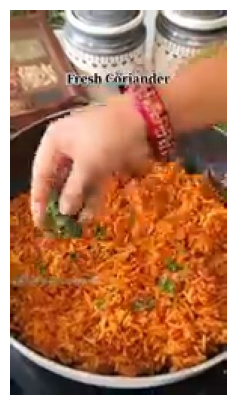

Caption: a person cooking food in a pan on a stove
Frame: Clip_02 Tomato Garlic Rice_6.jpg


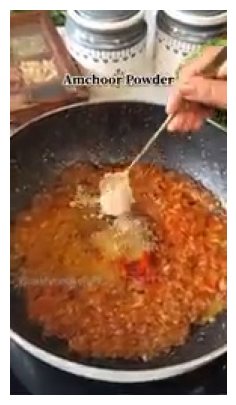

Caption: a kitchen with a stove, sink and a microwave
Frame: Clip_03 Girl Makaing Breakfast_5.jpg


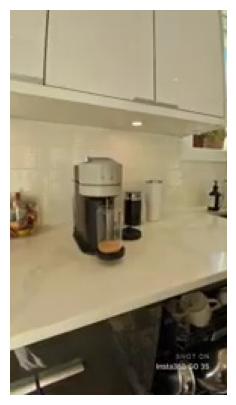

Caption: a woman is cooking food on a stove
Frame: Clip_03 Girl Makaing Breakfast_2.jpg


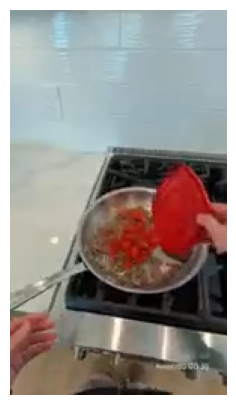

Caption: a person is cooking rice in a pan
Frame: Clip_02 Tomato Garlic Rice_8.jpg


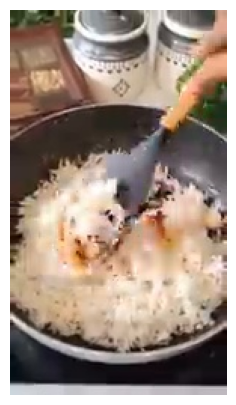

In [17]:
from PIL import Image
import matplotlib.pyplot as plt
import os

for i in range(len(results["ids"][0])):

    caption = results["documents"][0][i]

    frame = results["metadatas"][0][i]["frame"]

    print("="*60)
    print("Caption:", caption)
    print("Frame:", frame)

    image = Image.open(os.path.join("frames", frame))

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [18]:
query = input("Ask about the videos: ")

query_embedding = embedding_model.encode(query).tolist()

results = collection.query(
    query_embeddings=[query_embedding],
    n_results=5
)

results

Ask about the videos: Forest


{'ids': [['38', '36', '34', '8', '42']],
 'embeddings': None,
 'documents': [['a lake with trees and mountains in the background',
   'a river with trees and water in the background',
   'a person walking down a wooden path in the woods',
   'a wooden cutting board with a knife and a plant',
   'a woman walking down a wooden path in the woods']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'frame': 'Clip_5 walking and hiking_5.jpg'},
   {'frame': 'Clip_5 walking and hiking_3.jpg'},
   {'frame': 'Clip_5 walking and hiking_10.jpg'},
   {'frame': 'Clip_02 Tomato Garlic Rice_0.jpg'},
   {'frame': 'Clip_5 walking and hiking_9.jpg'}]],
 'distances': [[0.5388672947883606,
   0.5870814919471741,
   0.6796295642852783,
   0.691676139831543,
   0.7556537389755249]]}

Caption: a lake with trees and mountains in the background
Frame: Clip_5 walking and hiking_5.jpg


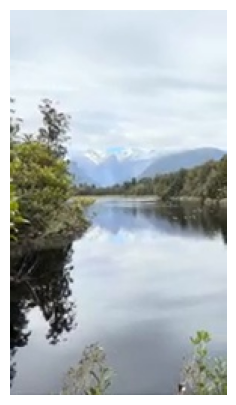

Caption: a river with trees and water in the background
Frame: Clip_5 walking and hiking_3.jpg


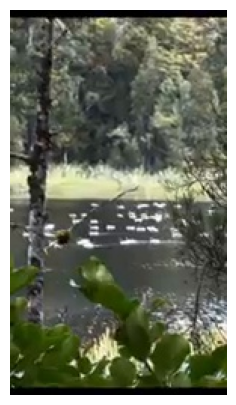

Caption: a person walking down a wooden path in the woods
Frame: Clip_5 walking and hiking_10.jpg


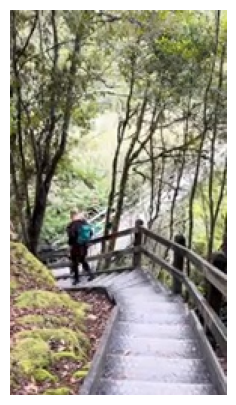

Caption: a wooden cutting board with a knife and a plant
Frame: Clip_02 Tomato Garlic Rice_0.jpg


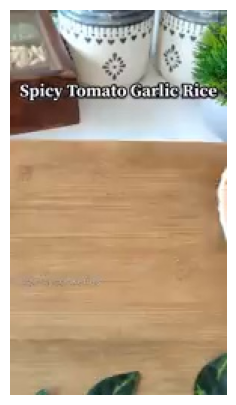

Caption: a woman walking down a wooden path in the woods
Frame: Clip_5 walking and hiking_9.jpg


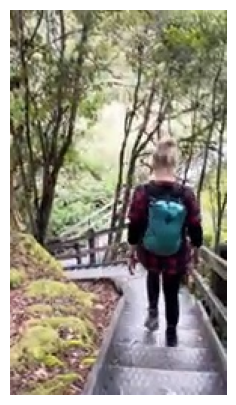

In [19]:
from PIL import Image
import matplotlib.pyplot as plt
import os

for i in range(len(results["ids"][0])):

    caption = results["documents"][0][i]

    frame = results["metadatas"][0][i]["frame"]

    print("="*60)
    print("Caption:", caption)
    print("Frame:", frame)

    image = Image.open(os.path.join("frames", frame))

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()